<a href="https://colab.research.google.com/github/Viktoriia-code26/goit_data_Hw3/blob/main/Hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
X_raw = df[['area', 'bedrooms', 'bathrooms']]
y = df['price'].values

X_scaled = (X_raw - X_raw.mean()) / X_raw.std()
X = np.c_[np.ones(X_scaled.shape[0]), X_scaled]


In [ ]:
# напишіть функцію гіпотези лінійної регресії у векторному вигляді;
def hypothesis(X, w):
    return X @ w

In [ ]:
 # створіть функцію для обчислення функції втрат у векторному вигляді;
def loss_function(X, y, w):
    m = len(y)
    y_pred = X @ w
    return np.sum((y_pred - y) ** 2) / (2 * m)


In [ ]:
#  А sklearn используем для проверки
w = np.zeros(X.shape[1])

y_pred = X @ w
print(loss_function(X, y, w))
print(mean_squared_error(y, y_pred) / 2)


13106916364659.266
13106916364659.266


In [ ]:
# реалізуйте один крок градієнтного спуску;
def gradient_step(X, y, w, learning_rate):
    m = len(y)
    predictions = hypothesis(X, w)
    errors = predictions - y
    gradient = (1 / m) * X.T @ errors
    w = w - learning_rate * gradient
    return w

In [ ]:
# знайдіть найкращі параметри w для датасету використовуючи написані вами функції, прогнозуючу ціну на будинок залежно від площі, кількості ванних кімнат та кількості спалень;
def gradient_descent(X, y, w, learning_rate, iterations):
    losses = []

    for i in range(iterations):
        w = gradient_step(X, y, w, learning_rate)
        loss = loss_function(X, y, w)
        losses.append(loss)

    return w, losses

w_start = np.zeros(X.shape[1])

w_gradient, losses = gradient_descent(
    X,
    y,
    w_start,
    learning_rate=0.01,
    iterations=1000
)

print(w_gradient)
print(losses[-1])


[4766523.46205873  821953.24685936  300575.90579754  696151.64754558]
895585105246.4731


In [ ]:
# знайдіть ці ж параметри за допомогою аналітичного рішення;
w_analytical = np.linalg.pinv(X.T @ X) @ X.T @ y

print(w_analytical)
print(loss_function(X, y, w_analytical))

[4766729.24770642  821968.58935343  300259.16468032  696447.75898579]
895585024988.6597


In [ ]:
# для перевірки спрогнозованих значень, використайте LinearRegression з бібліотеки scikit-learn та порівняйте результат
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

w_sklearn = model.coef_

y_pred_sklearn = model.predict(X)

print(w_sklearn)
print(mean_squared_error(y, y_pred_sklearn) / 2)
print(r2_score(y, y_pred_sklearn))

print("Gradient descent w:")
print(w_gradient)

print("Analytical w:")
print(w_analytical)

print("Sklearn w:")
print(w_sklearn)

print("GD loss:", loss_function(X, y, w_gradient))
print("Analytical loss:", loss_function(X, y, w_analytical))
print("Sklearn loss:", mean_squared_error(y, y_pred_sklearn) / 2)

[4766729.24770642  821968.58935343  300259.16468032  696447.7589858 ]
895585024988.6597
0.4870830667058762
Gradient descent w:
[4766523.46205873  821953.24685936  300575.90579754  696151.64754558]
Analytical w:
[4766729.24770642  821968.58935343  300259.16468032  696447.75898579]
Sklearn w:
[4766729.24770642  821968.58935343  300259.16468032  696447.7589858 ]
GD loss: 895585105246.4731
Analytical loss: 895585024988.6597
Sklearn loss: 895585024988.6597


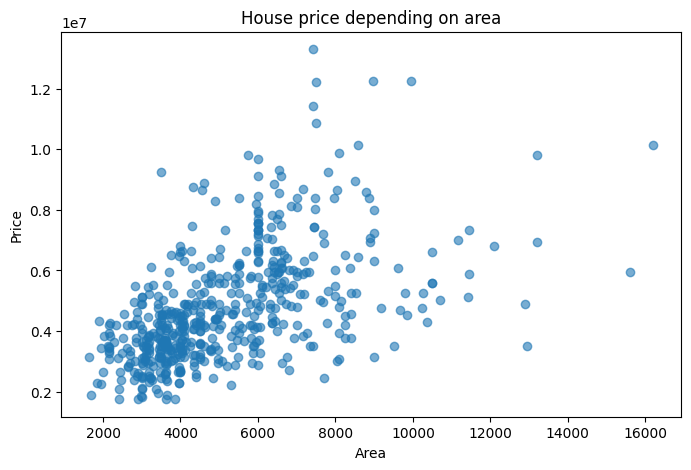

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['area'], df['price'], alpha=0.6)

plt.xlabel('Area')
plt.ylabel('Price')
plt.title('House price depending on area')

plt.show()

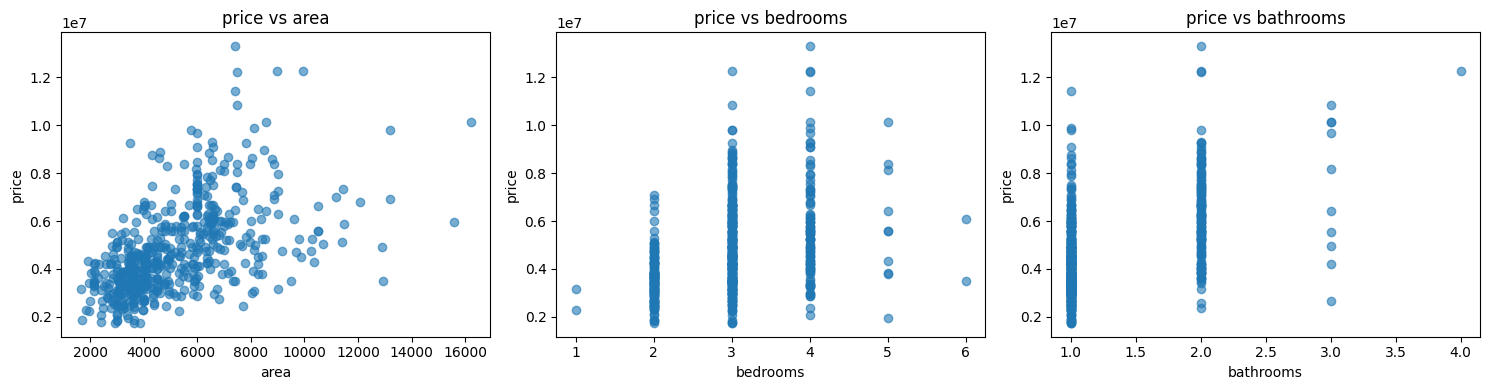

In [ ]:
features = ['area', 'bedrooms', 'bathrooms']

plt.figure(figsize=(15, 4))

for i, feature in enumerate(features):
    plt.subplot(1, 3, i + 1)
    plt.scatter(df[feature], df['price'], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel('price')
    plt.title(f'price vs {feature}')

plt.tight_layout()
plt.show()

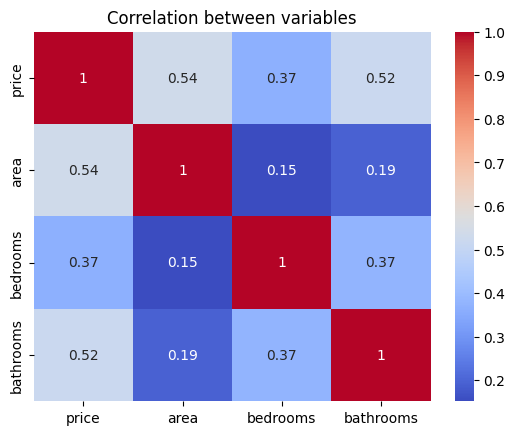

In [ ]:
columns = ['price', 'area', 'bedrooms', 'bathrooms']

sns.heatmap(df[columns].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between variables')
plt.show()


### **Висновок**

> У ході виконання лабораторної роботи було побудовано модель лінійної регресії для прогнозування вартості будинку залежно від його характеристик. Модель була реалізована трьома способами: за допомогою градієнтного спуску, аналітичного розв'язку та бібліотеки **scikit-learn**. Отримані результати є близькими, що підтверджує правильність реалізації моделі.
>
> Аналіз графіків показав, що **ціна будинку (`price`) найбільше залежить від площі (`area`)**, а також помітний позитивний зв'язок із кількістю ванних кімнат (`bathrooms`) та спалень (`bedrooms`).
>
> Кореляційна матриця підтвердила, що найбільшу кореляцію з ціною має **площа будинку (`r ≈ 0.54`)**, далі — **кількість ванних кімнат (`r ≈ 0.52`)**. Зв'язок між кількістю спалень і ціною є слабшим (**`r ≈ 0.37`**). Сильних кореляцій між незалежними ознаками не виявлено, тому суттєвої мультиколінеарності немає.
>
> Отже, лінійна регресія є придатною для оцінки вартості будинку за його основними характеристиками, а отримані результати підтверджують коректність побудованої моделі.

Такой вывод соответствует тому, что у вас есть в ноутбуке: сравнение трёх способов обучения, диаграммы рассеяния и тепловая карта корреляций.

